# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

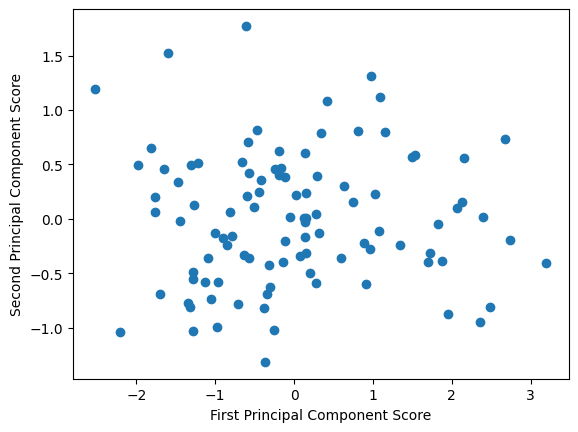

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

What can be said about the three outliers in the upper left corner of the graph? 
  - The three outliers have a low PC1 and a high PC2 score, meaning the data is far below the direction of the firs eigenvector and significantly higher from the second eignenvector. This translates to the data being outside (lower) than the general spread of the data and outside (higher) than the orthogonal (perpendicular) spread of the data.
 
Is their first principal component score high or low?
  - Their first principal component is low.  
 
What about their second principal component score?  
  - Their second principal component is high.
 
What does that mean about their values in series_1, series_2, and series_3?  
  - series_1: outliers are likely above the mean because they have a high PC2 score.
  - series_2: outliers are likely above the mean because because they have a high PC2 score.
  - series_3: outliers are likely significantly below the mean because they have a low PC1 score.
 
It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  
  - This is because series_3 has a higher scale than the others while series_1 and series_2 are highly correlated.
 
How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.
  - They are related because series_2 is a direct function of series_1 with a more similar scale (0.1) compared to series_3 which has a larger scale (0.5).
  
Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?
  - Compared to PCA, this graph shows the actual data rather than the "summary" of how the majority of the data lies. You can see the individual feature relationships and distributions. One major disadvantage for pairplots are if there are a lot of features because it creates an n x n grid. Interestingly, series_1 and series_2 are highly correlated while the other feature relationships are more scattered and less defined linearly.

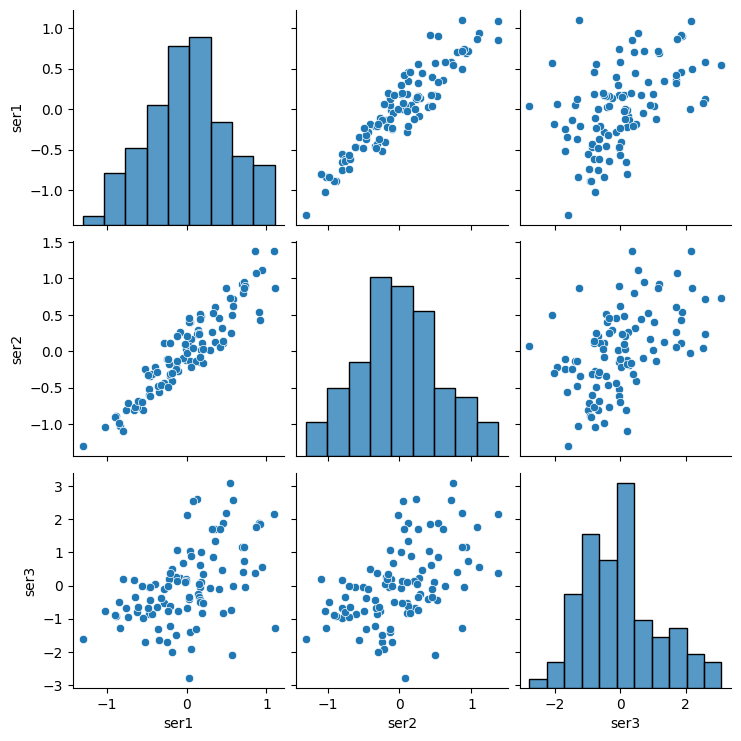

In [3]:
sns.pairplot(df)

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [6]:
cancer_rates = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(COMBINED) Cancer Rates.csv")
cancer_deaths = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(COMBINED) cancer_deaths.csv")
census_pop = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(IMPUTED) census_pop_county.csv")
house_income = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(IMPUTED) RESHAPED Unemployment and median household income.csv")
life_expect_kff = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\KFF - life expectancy at birth by race.csv")
life_expect_nchs = pd.read_csv(r"..\Projects\Health Disparities Analytics\Processed Data\NCHS_-_Death_rates_and_life_expectancy_at_birth.csv")

##### Heatmaps

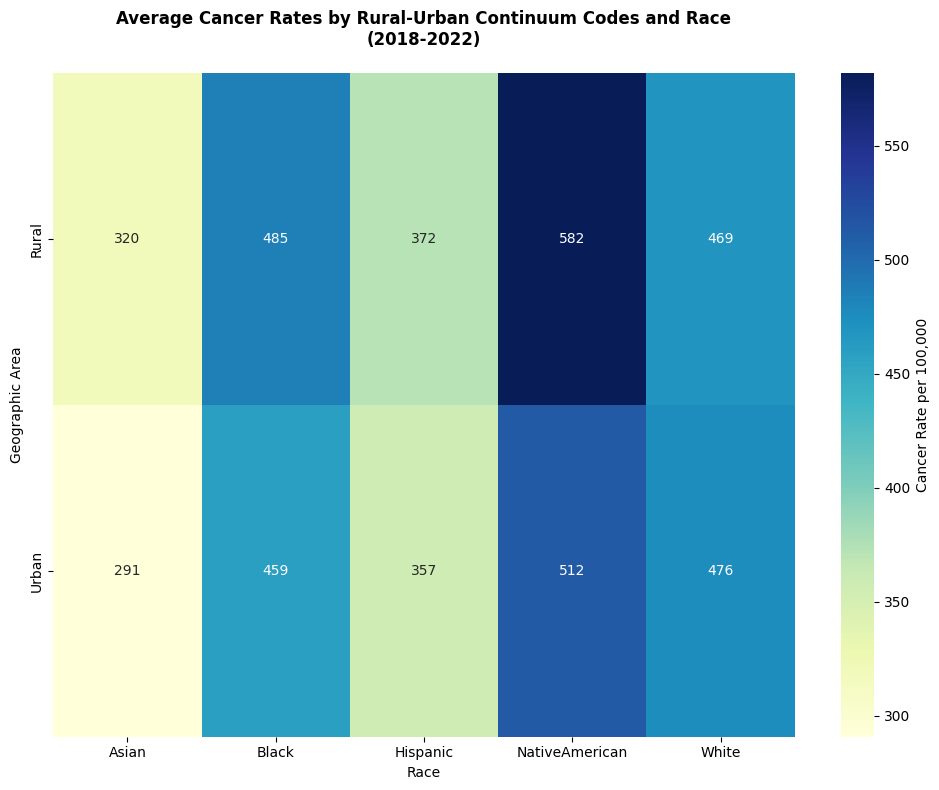

In [ ]:
# cancer_rates.info()

# Need to remove data for flagged values so the data isn't skewed on the visuals

flag_map = {
    '*': -9999,
    '[P1 note]': -9998,
    '[P3 note]': -9997,
    '[S3 note]': -9996,
    '&para': -9995,

    'rising': -8888,
    'falling': -8887,
    'stable': -8886
}

flag_values = list(flag_map.values())

cancer_rates_filtered = cancer_rates.copy()
cancer_rates_filtered['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'] = cancer_rates_filtered['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'].replace(flag_values, np.nan)

cancer_rates_pivot = cancer_rates_filtered.pivot_table(
    index="2023 Rural-Urban Continuum Codes([rural urban note])", 
    columns="Race", 
    values="Age-Adjusted Incidence Rate([rate note]) - cases per 100,000", 
    aggfunc='median'  
)

plt.figure(figsize=(10, 8))

sns.heatmap(cancer_rates_pivot, 
            annot=True, 
            cmap="YlGnBu", 
            fmt='.0f',
            cbar_kws={'label': 'Cancer Rate per 100,000'})

plt.title("Average Cancer Rates by Rural-Urban Continuum Codes and Race\n(2018-2022)", pad=20, fontweight='bold')
plt.ylabel("Geographic Area")
plt.tight_layout()
plt.show()

Geographic Areas:
  - Rural: All racial groups have higher cancer rates compared to Urban areas

Race:
  - Native Americans have the highest cancer rates compared to all other racial group
  - White people have the second highest cancer rates
  - Black people have the third highest cancer rates

Note:
  - The data is still skewed because there are significantly more data for White people compared to all other racial groups. 

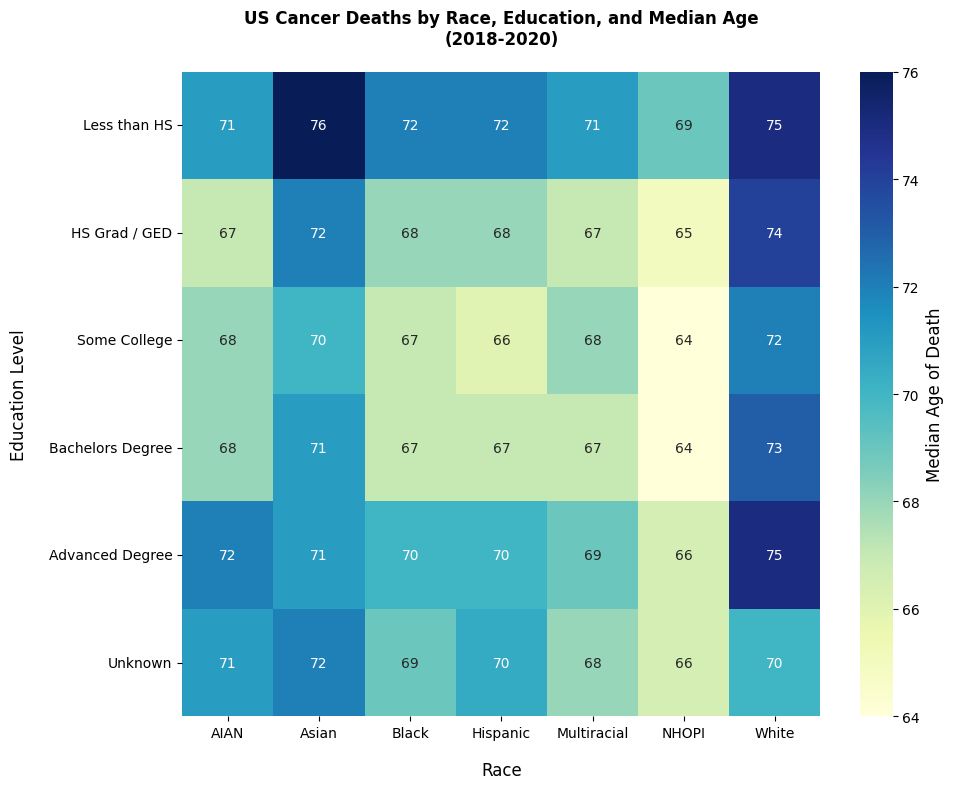

In [48]:
# cancer_deaths.info()

edu_order = [
    "Less than HS",
    "HS Grad / GED",
    "Some College",
    "Bachelors Degree",
    "Advanced Degree",
    "Unknown"
]

cancer_death_pivot = cancer_deaths.pivot_table(
    index="EDUCATION", 
    columns="RACE", 
    values="AGE", 
    aggfunc='median'  
)

# Order the data by the EDUCATION order I set above
cancer_death_pivot = cancer_death_pivot.reindex(edu_order)

plt.figure(figsize=(10, 8))

ax = sns.heatmap(cancer_death_pivot, 
            annot=True, 
            cmap="YlGnBu", 
            cbar_kws={'label': 'Median Age of Death'})

# Access the colorbar to adjust the label size
ax.figure.axes[-1].yaxis.label.set_size(12)

plt.title("US Cancer Deaths by Race, Education, and Median Age\n(2018-2020)", pad=20, fontweight='bold')

plt.xlabel("Race", labelpad=15, fontsize=12)
plt.ylabel("Education Level", labelpad=15, fontsize=12)
plt.tight_layout()
plt.show()

Education:
  - Less than HS and Advanced Degree seem to have the highest cancer deaths compared to other educational attainment categories
  - HS Grad / GED, Some College, and Bachelors Degree tend to have the lowest median age of death from cancer

Races:
  - White people have the oldest median age of death from cancer compared to all other races
  - Native Hawaiian and Other Pacific Islander people (NHOPI) have the lowest median age of death from cancer

##### Bubble Plots

##### PCA

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.